# Project 3 — Notebook 10: Priority & SLA Matrix
### NCR Zone-Level Performance Decomposed by Priority-Urgency Tier

---

**Questions this notebook answers:**
1. What is the Priority-Urgency mix per zone — and does it differ enough to make
   raw SLA comparisons misleading?
2. Which Priority-Urgency tiers are driving SLA breaches, and in which zones?
3. Is zone MTTR variance partly explained by handling a harder ticket mix?

**SLA threshold reference (from config):**

| Priority | Scope | U1 — Outage | U2 — Degradation | U3 — Mgmt Alarm |
|----------|-------|-------------|------------------|-----------------|
| P1 | Core equipment · national impact | 3h | 3h | 3h |
| P2 | Core equipment · regional impact | 6h | 6h | 6h |
| P3 | Zone equipment (e.g. BTS) · area impact | 9h | 12h | 24h |

> **Note:** No Priority 4 tickets exist in the current dataset — the P4 filter is a safeguard for future data.
> Within P3, urgency matters operationally: P3.1 is a site outage (9h target), P3.3 is a management alarm (24h target) — very different failure conditions.
>
> **P1 volume caveat:** Only 149 P1 tickets exist NCR-wide. No individual zone × P1 cell reaches the ≥50-ticket threshold for the breach heatmap (Section 4). P1 tier-level SLA rates in Section 3 are directionally useful but should be interpreted with caution given small sample sizes.


## 1. Setup
from fault_ticket_plots import plot_grouped_bar_by_zone

In [1]:
import sys, os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from IPython.display import display, Markdown
%matplotlib inline

os.chdir(os.path.join('..', '..'))
if os.path.abspath(os.getcwd()) not in sys.path:
    sys.path.insert(0, os.path.abspath(os.getcwd()))

from config import ZONE_ORDER, ZONE_PALETTE, SLA_THRESHOLDS
from src.visualization import plot_grouped_bar_by_zone

df      = pd.read_csv('output/cleaned_fault_ticket.csv')
df_zone = df[(df['ZONE'].isin(ZONE_ORDER)) & (df['Priority'] < 4)].copy()

# Priority label map for display
# Priority ≥ 4 excluded — P4+ tickets are preventive maintenance (scheduled work),
# not reactive faults. Including them distorts MTTR, SLA rates, and priority mix.
# Priority labels — scope and SLA target
# P1: national core  P2: regional core  P3: zone equipment (BTS-level)
# Urgency: 1=Outage · 2=Degradation · 3=Management Alarm
P_LABEL = {1:'P1 — National Core (3h)', 2:'P2 — Regional Core (6h)', 3:'P3 — Zone Equipment (9-24h)'}
P_COLORS = {'P1 — National Core (3h)':'#d62728',
            'P2 — Regional Core (6h)':'#ff7f0e',
            'P3 — Zone Equipment (9-24h)':'#1f77b4'}

print(f"✅ {len(df_zone):,} zoned tickets")
print(f"   Priority_Urgency combinations: {sorted(df_zone['Priority_Urgency'].unique())}")
print(f"   SLA_Compliant coverage: {df_zone['SLA_Compliant'].notna().sum():,} tickets")

✅ 36,907 zoned tickets
   Priority_Urgency combinations: [np.float64(1.1), np.float64(1.3), np.float64(2.1), np.float64(2.2), np.float64(2.3), np.float64(3.1), np.float64(3.2), np.float64(3.3)]
   SLA_Compliant coverage: 36,907 tickets


## 2. Priority-Urgency Mix by Zone

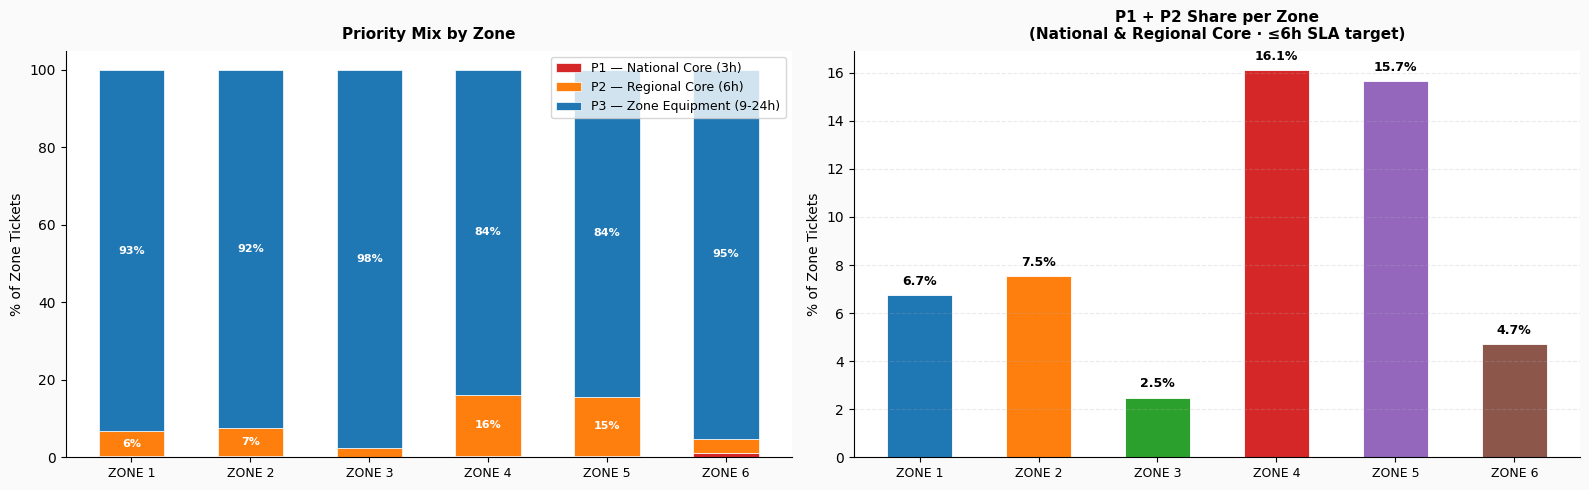

In [2]:
# Priority distribution per zone
df_zone['P_Label'] = df_zone['Priority'].map(P_LABEL)
p_order = ['P1 — National Core (3h)', 'P2 — Regional Core (6h)', 'P3 — Zone Equipment (9-24h)']

priority_mix = (df_zone.groupby(['ZONE','P_Label']).size()
                 .unstack(fill_value=0)
                 .reindex(columns=p_order, fill_value=0)
                 .reindex(ZONE_ORDER))
priority_mix_pct = priority_mix.div(priority_mix.sum(axis=1), axis=0) * 100


fig, axes = plt.subplots(1, 2, figsize=(16, 5))
fig.patch.set_facecolor('#fafafa')

# [Left] Stacked priority mix %
x = np.arange(len(ZONE_ORDER)); w = 0.55
bottom = np.zeros(len(ZONE_ORDER))
for p in p_order:
    vals = priority_mix_pct[p].values
    bars = axes[0].bar(x, vals, w, bottom=bottom,
                       color=P_COLORS[p], label=p, edgecolor='white', linewidth=0.5)
    for bar, val, bot in zip(bars, vals, bottom):
        if val > 4:
            axes[0].text(bar.get_x()+bar.get_width()/2, bot+val/2,
                         f'{val:.0f}%', ha='center', va='center',
                         fontsize=8, fontweight='bold', color='white')
    bottom += vals

axes[0].set_xticks(x)
axes[0].set_xticklabels(ZONE_ORDER, fontsize=9)
axes[0].set_ylim(0, 105)
axes[0].set_ylabel('% of Zone Tickets', fontsize=10)
axes[0].set_title('Priority Mix by Zone', fontsize=11, fontweight='bold', pad=8)
axes[0].legend(fontsize=9, loc='upper right', framealpha=0.8)
axes[0].spines['top'].set_visible(False)
axes[0].spines['right'].set_visible(False)

# [Right] P1+P2 share (highest-pressure tickets) per zone
high_prio_pct = (priority_mix_pct['P1 — National Core (3h)'] + priority_mix_pct['P2 — Regional Core (6h)']).reindex(ZONE_ORDER)
colors = [ZONE_PALETTE[z] for z in ZONE_ORDER]
bars = axes[1].bar(x, high_prio_pct, w, color=colors, edgecolor='white', linewidth=0.6)
for bar, val in zip(bars, high_prio_pct):
    axes[1].text(bar.get_x()+bar.get_width()/2, val+0.3,
                 f'{val:.1f}%', ha='center', va='bottom', fontsize=9, fontweight='bold')
axes[1].set_xticks(x)
axes[1].set_xticklabels(ZONE_ORDER, fontsize=9)
axes[1].set_ylabel('% of Zone Tickets', fontsize=10)
axes[1].set_title('P1 + P2 Share per Zone\n(National & Regional Core · ≤6h SLA target)',
                  fontsize=11, fontweight='bold', pad=8)
axes[1].grid(axis='y', alpha=0.25, linestyle='--')
axes[1].spines['top'].set_visible(False)
axes[1].spines['right'].set_visible(False)

plt.tight_layout()
os.makedirs('reports/figures/project3_ncr', exist_ok=True)
plt.savefig('reports/figures/project3_ncr/10_priority_mix.png', dpi=150, bbox_inches='tight')
plt.show()


## 3. SLA Compliance by Priority Tier × Zone

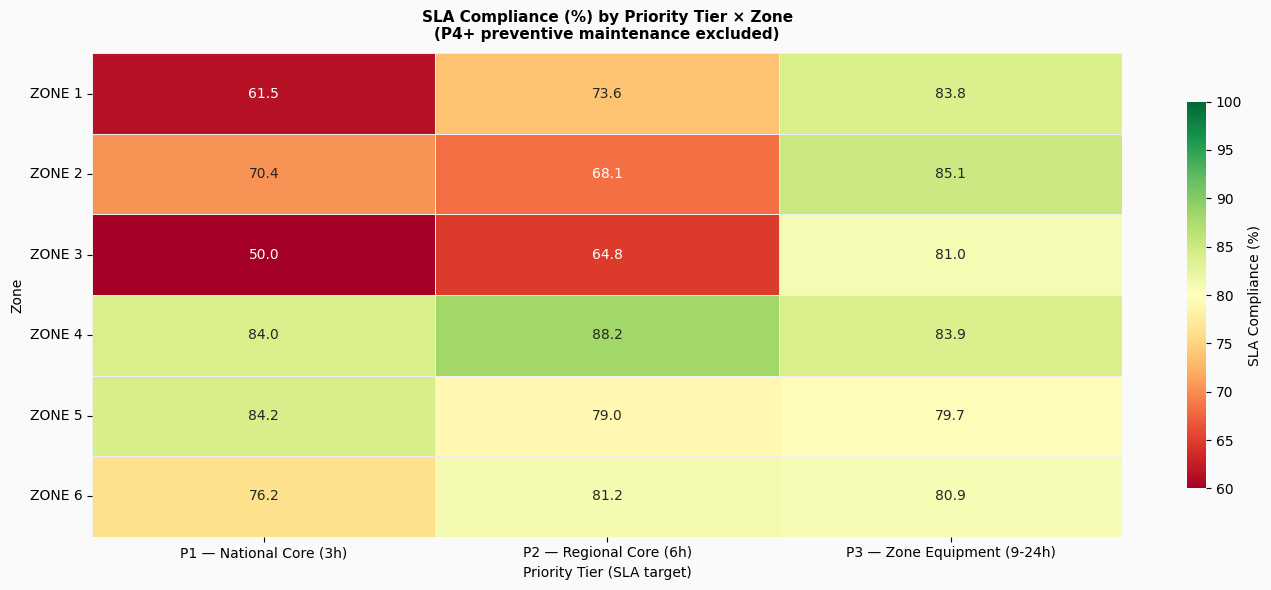


NCR avg SLA compliance: 82.2%

Zone × Tier combinations below NCR average:
  ZONE 1  P1 — National Core (3h)  61.5%  (gap: -20.6pp)
  ZONE 1  P2 — Regional Core (6h)  73.6%  (gap: -8.5pp)
  ZONE 2  P1 — National Core (3h)  70.4%  (gap: -11.8pp)
  ZONE 2  P2 — Regional Core (6h)  68.1%  (gap: -14.0pp)
  ZONE 3  P1 — National Core (3h)  50.0%  (gap: -32.2pp)
  ZONE 3  P2 — Regional Core (6h)  64.8%  (gap: -17.4pp)
  ZONE 3  P3 — Zone Equipment (9-24h)  81.0%  (gap: -1.2pp)
  ZONE 5  P2 — Regional Core (6h)  79.0%  (gap: -3.1pp)
  ZONE 5  P3 — Zone Equipment (9-24h)  79.7%  (gap: -2.5pp)
  ZONE 6  P1 — National Core (3h)  76.2%  (gap: -6.0pp)
  ZONE 6  P2 — Regional Core (6h)  81.2%  (gap: -1.0pp)
  ZONE 6  P3 — Zone Equipment (9-24h)  80.9%  (gap: -1.3pp)


In [3]:
df_pu = df_zone.copy()

sla_pu = (df_pu.groupby(['ZONE','P_Label'])['SLA_Compliant']
           .mean().mul(100)
           .unstack(fill_value=np.nan)
           .reindex(columns=p_order, fill_value=np.nan)
           .reindex(ZONE_ORDER))

fig, ax = plt.subplots(figsize=(14, 6))
fig.patch.set_facecolor('#fafafa')

# Heatmap with annotation
mask = sla_pu.isna()
from src.visualization.common_plots import plot_heatmap
plot_heatmap(ax, sla_pu, pivot=False,
             title='SLA Compliance (%) by Priority Tier × Zone\n(P4+ preventive maintenance excluded)',
             cmap='RdYlGn', fmt='.1f',
             vmin=60, vmax=100, mask=mask,
             cbar_label='SLA Compliance (%)', cbar_shrink=0.8,
             x_label='Priority Tier (SLA target)', y_label='Zone',
             x_rotation=0, y_rotation=0)

plt.tight_layout()
plt.savefig('reports/figures/project3_ncr/10_sla_priority_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

# Which zone × tier combinations are below NCR average?
ncr_avg_sla = df_pu['SLA_Compliant'].mean() * 100
print(f"\nNCR avg SLA compliance: {ncr_avg_sla:.1f}%")
print(f"\nZone × Tier combinations below NCR average:")
for zone in ZONE_ORDER:
    for p in p_order:
        val = sla_pu.loc[zone, p]
        if pd.notna(val) and val < ncr_avg_sla:
            print(f"  {zone}  {p:<14}  {val:.1f}%  (gap: -{ncr_avg_sla-val:.1f}pp)")

## 4. SLA Breach Rate Heatmap — Zone × Priority.Urgency

> This is the key chart for P3: separates P3.1 (Outage · 9h), P3.2 (Degradation · 12h), and P3.3 (Mgmt Alarm · 24h) so breach patterns are visible at the urgency level, not just priority level.
>
> **P1 absent from heatmap:** Only 149 P1 tickets exist across all zones — no zone × P1.x cell reaches the ≥50 ticket minimum. P2.1 also absent in most zones for the same reason.

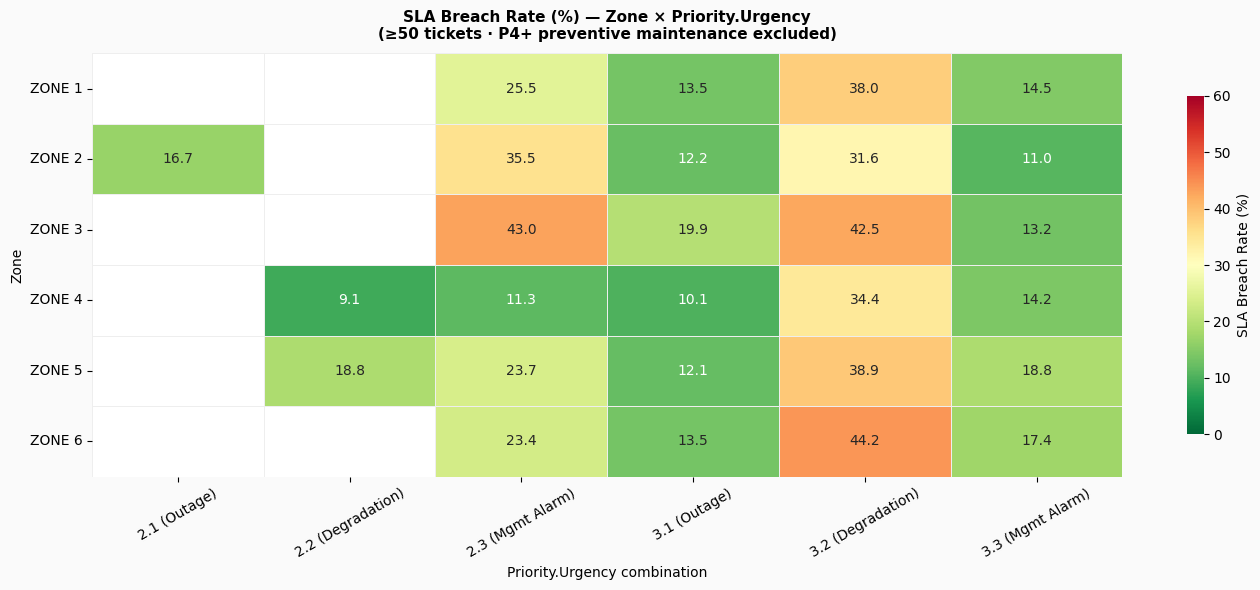

In [4]:
# Full PU combination breach rate — identify specific worst-performing cells
df_pu2 = df_zone.copy()

# Only PU combos with meaningful volume (≥50 tickets)
pu_sla = (df_pu2.groupby(['ZONE','Priority_Urgency'])
           .agg(Tickets=('SLA_Compliant','count'),
                Breach_Rate=('SLA_Compliant', lambda x: (1 - x.mean()) * 100))
           .reset_index()
           .query('Tickets >= 50'))

# Pivot for heatmap
pu_pivot = pu_sla.pivot_table(index='ZONE', columns='Priority_Urgency',
                               values='Breach_Rate', fill_value=np.nan)
pu_pivot = pu_pivot.reindex(ZONE_ORDER)

# Sort columns by priority then urgency
col_order = sorted(pu_pivot.columns,
                   key=lambda x: (float(str(x).split('.')[0]), float(str(x).split('.')[1])))
pu_pivot = pu_pivot[[c for c in col_order]]
# Rename columns to show urgency meaning
U_LABEL = {'1': 'Outage', '2': 'Degradation', '3': 'Mgmt Alarm'}
pu_pivot.columns = [f"{c} ({U_LABEL.get(str(c).split('.')[1], str(c))})" for c in pu_pivot.columns]

fig, ax = plt.subplots(figsize=(14, 6))
fig.patch.set_facecolor('#fafafa')

mask = pu_pivot.isna()
from src.visualization.common_plots import plot_heatmap
plot_heatmap(ax, pu_pivot, pivot=False,
             title='SLA Breach Rate (%) — Zone × Priority.Urgency\n(≥50 tickets · P4+ preventive maintenance excluded)',
             cmap='RdYlGn_r', fmt='.1f',
             vmin=0, vmax=60, mask=mask,
             cbar_label='SLA Breach Rate (%)', cbar_shrink=0.8,
             x_label='Priority.Urgency combination', y_label='Zone',
             x_rotation=30, y_rotation=0)

plt.tight_layout()
plt.savefig('reports/figures/project3_ncr/10_breach_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

## 5. MTTR Decomposed by Priority Tier

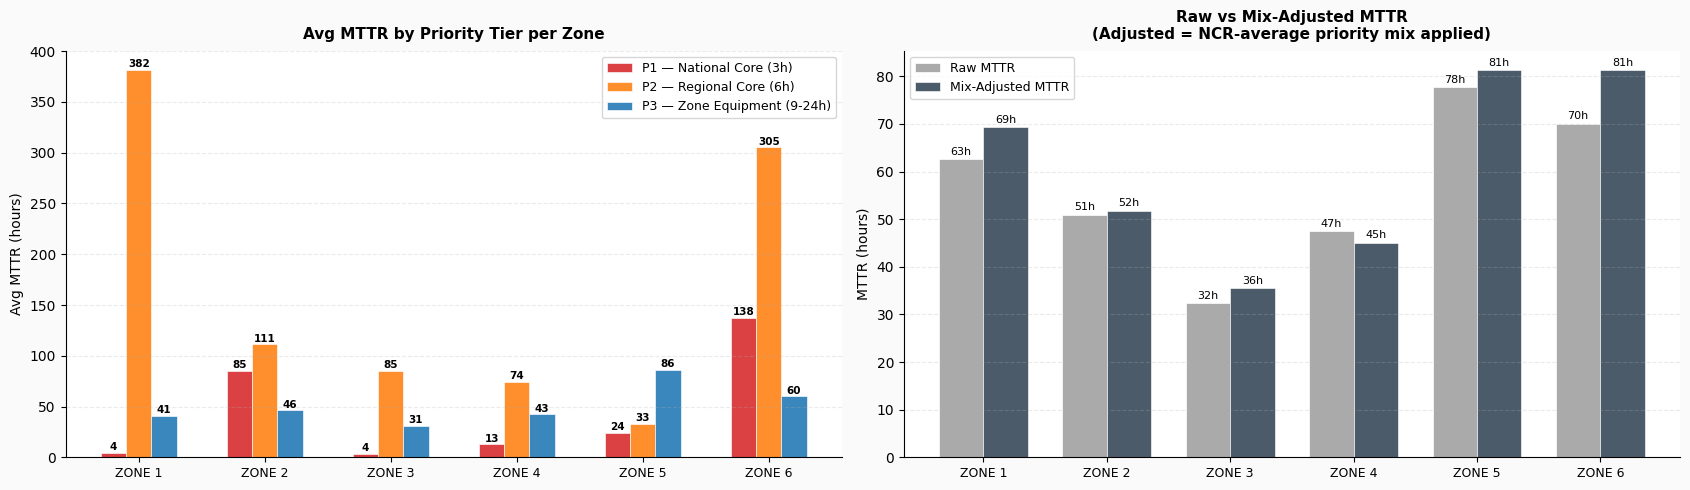


Raw vs Mix-Adjusted MTTR:
  Caveat: P2 MTTR is inflated by outliers in Zone 1 (381.6h) and Zone 6 (305.4h).
  Mix-adjusted values incorporating high NCR-avg P2 weight should be read with this in mind.
  ZONE 1: Raw 63h → Adjusted 69h  (↑ 6.8h harder mix)
  ZONE 2: Raw 51h → Adjusted 52h  (↑ 0.9h harder mix)
  ZONE 3: Raw 32h → Adjusted 36h  (↑ 3.2h harder mix)
  ZONE 4: Raw 47h → Adjusted 45h  (↓ 2.4h easier mix)
  ZONE 5: Raw 78h → Adjusted 81h  (↑ 3.6h harder mix)
  ZONE 6: Raw 70h → Adjusted 81h  (↑ 11.3h harder mix)


In [5]:
# Does zone MTTR variance reflect ticket mix or genuine performance differences?
mttr_tier = (df_zone.groupby(['ZONE','P_Label'])['OUTAGEDURATION']
              .mean()
              .unstack(fill_value=np.nan)
              .reindex(columns=p_order, fill_value=np.nan)
              .reindex(ZONE_ORDER))

fig, axes = plt.subplots(1, 2, figsize=(17, 5))
fig.patch.set_facecolor('#fafafa')

# [Left] MTTR by priority tier × zone
plot_grouped_bar_by_zone(
    axes[0], mttr_tier, ZONE_ORDER,
    col_order  = p_order,
    col_colors = list(P_COLORS.values()),
    col_labels = p_order,
    ylabel='Avg MTTR (hours)',
    title='Avg MTTR by Priority Tier per Zone',
    fmt='{:.0f}', annotate_threshold=2, bar_width=0.2,
)

# [Right] Raw vs mix-adjusted MTTR
ncr_p_mix = priority_mix_pct.mean()
adj_mttr  = (mttr_tier * (ncr_p_mix / 100)).sum(axis=1)
raw_mttr  = df_zone.groupby('ZONE')['OUTAGEDURATION'].mean().reindex(ZONE_ORDER)

compare = pd.DataFrame({'Raw MTTR': raw_mttr, 'Mix-Adjusted MTTR': adj_mttr})
bw = 0.36; bar_x = np.arange(len(ZONE_ORDER))
axes[1].bar(bar_x - bw/2, compare['Raw MTTR'],          bw,
            label='Raw MTTR', color='#aaa', edgecolor='white', linewidth=0.5)
axes[1].bar(bar_x + bw/2, compare['Mix-Adjusted MTTR'], bw,
            label='Mix-Adjusted MTTR', color='#2c3e50', edgecolor='white',
            linewidth=0.5, alpha=0.85)
for i, (raw, adj) in enumerate(zip(compare['Raw MTTR'], compare['Mix-Adjusted MTTR'])):
    axes[1].text(i - bw/2, raw + 0.5, f'{raw:.0f}h', ha='center', va='bottom', fontsize=8)
    axes[1].text(i + bw/2, adj + 0.5, f'{adj:.0f}h', ha='center', va='bottom', fontsize=8)
axes[1].set_xticks(bar_x)
axes[1].set_xticklabels(ZONE_ORDER, fontsize=9)
axes[1].set_ylabel('MTTR (hours)', fontsize=10)
axes[1].set_title('Raw vs Mix-Adjusted MTTR\n(Adjusted = NCR-average priority mix applied)',
                  fontsize=11, fontweight='bold', pad=8)
axes[1].legend(fontsize=9, framealpha=0.8)
axes[1].grid(axis='y', alpha=0.25, linestyle='--')
axes[1].spines['top'].set_visible(False)
axes[1].spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig('reports/figures/project3_ncr/10_mttr_decomposed.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nRaw vs Mix-Adjusted MTTR:")
print("  Caveat: P2 MTTR is inflated by outliers in Zone 1 (381.6h) and Zone 6 (305.4h).")
print("  Mix-adjusted values incorporating high NCR-avg P2 weight should be read with this in mind.")
for zone in ZONE_ORDER:
    raw = raw_mttr[zone]; adj = adj_mttr[zone]; diff = raw - adj
    direction = f"↓ {abs(diff):.1f}h easier mix" if diff > 0 else f"↑ {abs(diff):.1f}h harder mix"
    print(f"  {zone}: Raw {raw:.0f}h → Adjusted {adj:.0f}h  ({direction})")


## 6. SLA Performance by Priority Tier — NCR Summary Table

> Note: SLA target shown is for U1 (Outage) as the representative threshold per priority.
> P3 targets vary by urgency: P3.1 = 9h · P3.2 = 12h · P3.3 = 24h.

In [6]:
# Summary table: for each zone × priority, volume + SLA rate + avg MTTR + SLA threshold
rows = []
for zone in ZONE_ORDER:
    for p_num, p_label in P_LABEL.items():
        subset = df_zone[(df_zone['ZONE']==zone) &
                         (df_zone['Priority']==p_num)]
        if len(subset) < 20:
            continue
        # Use U1 (Outage) threshold as representative — tightest within each priority
        # P3 note: actual targets are 9h (U1·Outage) / 12h (U2·Degradation) / 24h (U3·Mgmt)
        pu_key = f'{p_num}.1'
        threshold = SLA_THRESHOLDS.get(pu_key, 24)
        rows.append({
            'Zone'       : zone,
            'Priority'   : p_label,
            'Tickets'    : len(subset),
            'SLA_Target_U1' : f'≤{threshold}h (Outage · tightest)',
            'SLA_Rate'   : subset['SLA_Compliant'].mean() * 100,
            'Avg_MTTR'   : subset['OUTAGEDURATION'].mean(),
            'Breach_Count': int((subset['SLA_Compliant']==0).sum()),
        })

tbl = pd.DataFrame(rows)

display(Markdown("### SLA Performance by Zone × Priority (≥20 tickets)"))
display(tbl.style
    .hide(axis='index')
    .format({'Tickets':'{:,}','SLA_Rate':'{:.1f}%',
             'Avg_MTTR':'{:.0f}h','Breach_Count':'{:,}'})
    # P3 rows cover all urgencies together; see heatmap in Section 4 for per-urgency detail
    .background_gradient(subset=['SLA_Rate'],    cmap='RdYlGn', vmin=60, vmax=100)
    .background_gradient(subset=['Avg_MTTR'],    cmap='RdYlGn_r', vmin=10, vmax=120)
    .background_gradient(subset=['Breach_Count'],cmap='Reds')
    .set_caption('Table 1 — SLA Performance by Zone × Priority  |  P4+ excluded')
    .set_table_styles([
        {'selector':'caption','props':[('font-size','12px'),('font-weight','bold'),
                                        ('text-align','left'),('padding-bottom','6px')]},
        {'selector':'th','props':[('background-color','#2c3e50'),('color','white'),
                                   ('font-size','11px'),('padding','7px 10px')]},
        {'selector':'td','props':[('padding','6px 10px'),('font-size','11px'),
                                   ('text-align','center')]},
        {'selector':'tr:nth-child(even)','props':[('background-color','#f7f9fc')]},
    ])
)

### SLA Performance by Zone × Priority (≥20 tickets)

Zone,Priority,Tickets,SLA_Target_U1,SLA_Rate,Avg_MTTR,Breach_Count
ZONE 1,P2 — Regional Core (6h),277,≤6h (Outage · tightest),73.6%,382h,73
ZONE 1,P3 — Zone Equipment (9-24h),"4,016",≤9h (Outage · tightest),83.8%,41h,651
ZONE 2,P1 — National Core (3h),27,≤3h (Outage · tightest),70.4%,85h,8
ZONE 2,P2 — Regional Core (6h),524,≤6h (Outage · tightest),68.1%,111h,167
ZONE 2,P3 — Zone Equipment (9-24h),"6,756",≤9h (Outage · tightest),85.1%,46h,"1,004"
ZONE 3,P2 — Regional Core (6h),105,≤6h (Outage · tightest),64.8%,85h,37
ZONE 3,P3 — Zone Equipment (9-24h),"4,284",≤9h (Outage · tightest),81.0%,31h,814
ZONE 4,P1 — National Core (3h),25,≤3h (Outage · tightest),84.0%,13h,4
ZONE 4,P2 — Regional Core (6h),"1,257",≤6h (Outage · tightest),88.2%,74h,148
ZONE 4,P3 — Zone Equipment (9-24h),"6,670",≤9h (Outage · tightest),83.9%,43h,"1,077"


## 7. Next Steps

→ **Notebook 11** — Cross-Zone Benchmark Scorecard: priority-adjusted ranking.